# Doublet analysis (scDblFinder) K45678B

In [1]:
#Load packages
options(warn=-1)
library("IRdisplay")
library(tidyverse)
library(ggplot2)
library(Seurat)
library(scDblFinder)

── Attaching packages ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse 1.3.2 ──
✔ ggplot2 3.3.6      ✔ purrr   0.3.4 
✔ tibble  3.1.8      ✔ dplyr   1.0.10
✔ tidyr   1.2.1      ✔ stringr 1.4.1 
✔ readr   2.1.2      ✔ forcats 0.5.2 
── Conflicts ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
Attaching SeuratObject



In [2]:
suppressMessages(source("code/functions.R"))

### Load expression data

In [3]:
K4B <- readRDS("output/K4B.rds")
K5B <- readRDS("output/K5B.rds")
K6B <- readRDS("output/K6B.rds")
K7B <- readRDS("output/K7B.rds")
K8B <- readRDS("output/K8B.rds")

### Load df with filtered SHMss events (trully positive)

In [4]:
df_summary <- read.csv("output/df_summary_K45678_v5.csv")
head(df_summary)

,subject,cell,vgene_position_aligned,nucl_po,context_po,subregion,variation,umis,productive
,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<lgl>
1,K4B_S8934-HC,TGTCCCAGTTTGTTGG,4,G,AG.TG,FR1,A-G,18-8,TRUE
2,K4B_S8934-HC,TGAGAGGCAGACTCGC,9,G,CA.CT,FR1,A-G,34-69,TRUE
3,K4B_S8934-HC,AGATCTGAGACCGGAT,18,G,GA.TC,FR1,A-G,6-5,TRUE
4,K4B_S8934-HC,AGGCCGTGTGCGCTTG,70,G,CA.CC,FR1,A-G,5-5,TRUE
5,K4B_S8934-HC,CTTTGCGTCAAGGTAA,186,C,TA.GC,FR3,C-T,22-22,TRUE
6,K4B_S8934-HC,GGACGTCTCGACCAGC,188,C,CG.TG,FR3,C-G,8-5,TRUE


## Run scDblFinder

In [5]:
# sce_K4B <- scDblFinder(as.SingleCellExperiment(K4B))

# #Convert as df the scDblFinder results (singlet >< doublet)
# dbl_K4B <- as.data.frame(sce_K4B@colData) 

# table(sce_K4B$scDblFinder.class)

Creating ~5655 artificial doublets...

Dimensional reduction

Evaluating kNN...

Training model...

iter=0, 525 cells excluded from training.

iter=1, 915 cells excluded from training.

iter=2, 931 cells excluded from training.

Threshold found:0.4

934 (9.9%) doublets called


singlet doublet 
   8491     934 

In [6]:
# sce_K5B <- scDblFinder(as.SingleCellExperiment(K5B))

# #Convert as df the scDblFinder results (singlet >< doublet)
# dbl_K5B <- as.data.frame(sce_K5B@colData) 

# table(sce_K5B$scDblFinder.class)

In [7]:
# sce_K6B <- scDblFinder(as.SingleCellExperiment(K6B))

# #Convert as df the scDblFinder results (singlet >< doublet)
# dbl_K6B <- as.data.frame(sce_K6B@colData) 

# table(sce_K6B$scDblFinder.class)

Dimensional reduction

Evaluating kNN...

Training model...

iter=0, 1037 cells excluded from training.

iter=1, 1374 cells excluded from training.

iter=2, 1321 cells excluded from training.

Threshold found:0.383

1347 (11%) doublets called


singlet doublet 
  10852    1347 

In [8]:
# sce_K7B <- scDblFinder(as.SingleCellExperiment(K7B))

# #Convert as df the scDblFinder results (singlet >< doublet)
# dbl_K7B <- as.data.frame(sce_K7B@colData) 

# table(sce_K7B$scDblFinder.class)

Creating ~9788 artificial doublets...

Dimensional reduction

Evaluating kNN...

Training model...

iter=0, 3101 cells excluded from training.

iter=1, 3393 cells excluded from training.

iter=2, 3458 cells excluded from training.

Threshold found:0.381

3174 (19.5%) doublets called


singlet doublet 
  13138    3174 

In [9]:
# sce_K8B <- scDblFinder(as.SingleCellExperiment(K8B))

# #Convert as df the scDblFinder results (singlet >< doublet)
# dbl_K8B <- as.data.frame(sce_K8B@colData) 

# table(sce_K8B$scDblFinder.class)

Creating ~9896 artificial doublets...

Dimensional reduction

Evaluating kNN...

Training model...

iter=0, 3298 cells excluded from training.

iter=1, 3707 cells excluded from training.

iter=2, 3877 cells excluded from training.

Threshold found:0.429

3515 (21.3%) doublets called


singlet doublet 
  12978    3515 

In [10]:
# dou_k45678 <- bind_rows(dbl_K4B ,dbl_K5B ,dbl_K6B,dbl_K7B,dbl_K8B) %>% 
#                select(ident,scDblFinder.class, scDblFinder.score,nCount_RNA,nFeature_RNA) %>%
#                rownames_to_column("cell") %>%
#                mutate(cell = gsub("-.*$", "", cell)) %>%
#                rename("experiment"="ident")
# head(dou_k45678)

In [11]:
# head(dou_k45678)
# write.csv(dou_k45678, "output/doublet_in_K45678.csv")

In [12]:
#read doublet table
dou_k45678 <- read.csv("output/doublet_in_K45678.csv")

#aa %>% select(scDblFinder.class) %>% table() %>% mutate(. * 100 / total_cell)

In [13]:
# add doublet information to df
ft <-df_summary %>% mutate(experiment = str_sub(subject, 1, 3)) %>% left_join(dou_k45678 %>% select(cell,experiment,scDblFinder.class, scDblFinder.score,nCount_RNA,nFeature_RNA),c("cell","experiment")) 
head(ft)

,subject,cell,vgene_position_aligned,nucl_po,context_po,subregion,variation,umis,productive,experiment,scDblFinder.class,scDblFinder.score,nCount_RNA,nFeature_RNA
,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<lgl>,<chr>,<chr>,<dbl>,<int>,<int>
1,K4B_S8934-HC,TGTCCCAGTTTGTTGG,4,G,AG.TG,FR1,A-G,18-8,TRUE,K4B,singlet,0.27030772,6087,1972
2,K4B_S8934-HC,TGAGAGGCAGACTCGC,9,G,CA.CT,FR1,A-G,34-69,TRUE,K4B,singlet,0.03246965,6221,1981
3,K4B_S8934-HC,AGATCTGAGACCGGAT,18,G,GA.TC,FR1,A-G,6-5,TRUE,K4B,singlet,0.02154855,3528,1553
4,K4B_S8934-HC,AGGCCGTGTGCGCTTG,70,G,CA.CC,FR1,A-G,5-5,TRUE,K4B,singlet,0.01027268,4434,1781
5,K4B_S8934-HC,CTTTGCGTCAAGGTAA,186,C,TA.GC,FR3,C-T,22-22,TRUE,K4B,singlet,0.02883232,13578,3790
6,K4B_S8934-HC,GGACGTCTCGACCAGC,188,C,CG.TG,FR3,C-G,8-5,TRUE,K4B,singlet,0.01343021,11401,3290


In [14]:
# number of doublet
table(ft$scDblFinder.class)


singlet 
    294 

In [15]:
# add info about scSHM to doblet data for plotting
dou_k45678 <-  dou_k45678 %>%
                mutate(SHMa_pos=ifelse(cell %in% df_summary$cell, "Yes","No")) 

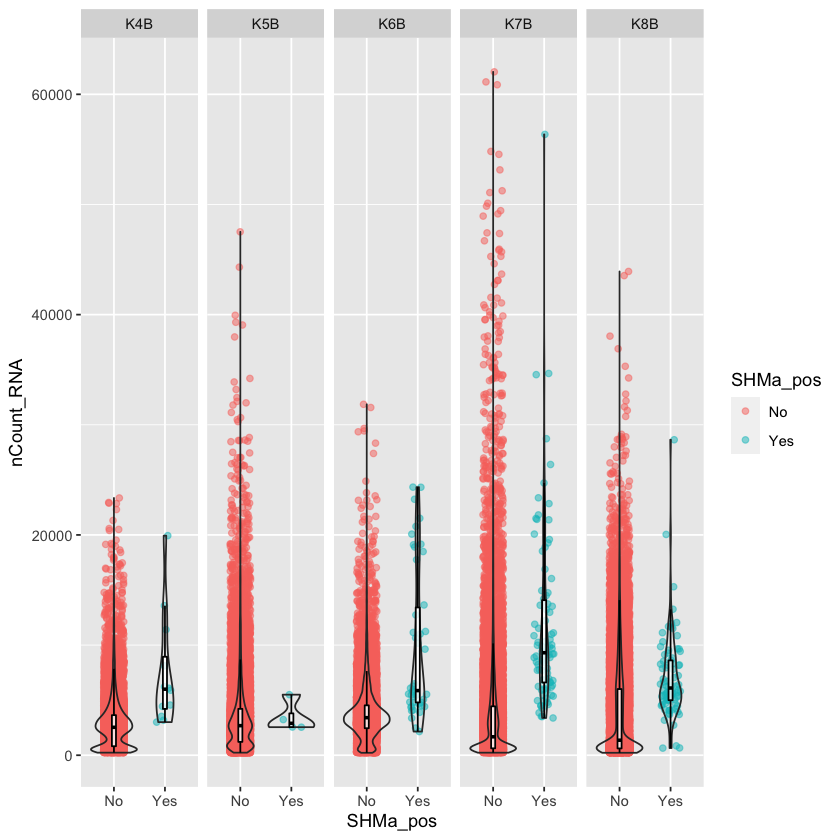

In [16]:
raw_con <- ggplot(dou_k45678, aes(y = nCount_RNA, x =SHMa_pos)) +
  geom_point(aes(colour = SHMa_pos),position = position_jitterdodge(seed = 1, dodge.width = 0.9), alpha=0.5) + #aes(colour = type)
    geom_violin(position = position_dodge(width = 0.9), alpha=0.8,fill =NA) +
       geom_boxplot(width = 0.08,position = position_dodge(width = 0.6),color="black",outlier.shape = NA,alpha=0.8 ) +
        facet_grid(.~experiment) 

fig_save(raw_con, filename = "figs/FL/raw_counts_SHM_events_K45678", formats = c("pdf", "png"), width = 20, height = 15, units = "cm", dpi = 320)

raw_con

In [17]:
# are the distribution different?
res <- wilcox.test(nCount_RNA ~ SHMa_pos, data = dou_k45678,
                   exact = FALSE)
res


	Wilcoxon rank sum test with continuity correction

data:  nCount_RNA by SHMa_pos
W = 2264374, p-value < 2.2e-16
alternative hypothesis: true location shift is not equal to 0


In [18]:
#perform Kolmogorov-Smirnov test (check if the distribution are different)
ks.test(dou_k45678$nCount_RNA[dou_k45678$SHMa_pos == "Yes"], dou_k45678$nCount_RNA[dou_k45678$SHMa_pos == "No"])


	Two-sample Kolmogorov-Smirnov test

data:  dou_k45678$nCount_RNA[dou_k45678$SHMa_pos == "Yes"] and dou_k45678$nCount_RNA[dou_k45678$SHMa_pos == "No"]
D = 0.60459, p-value < 2.2e-16
alternative hypothesis: two-sided


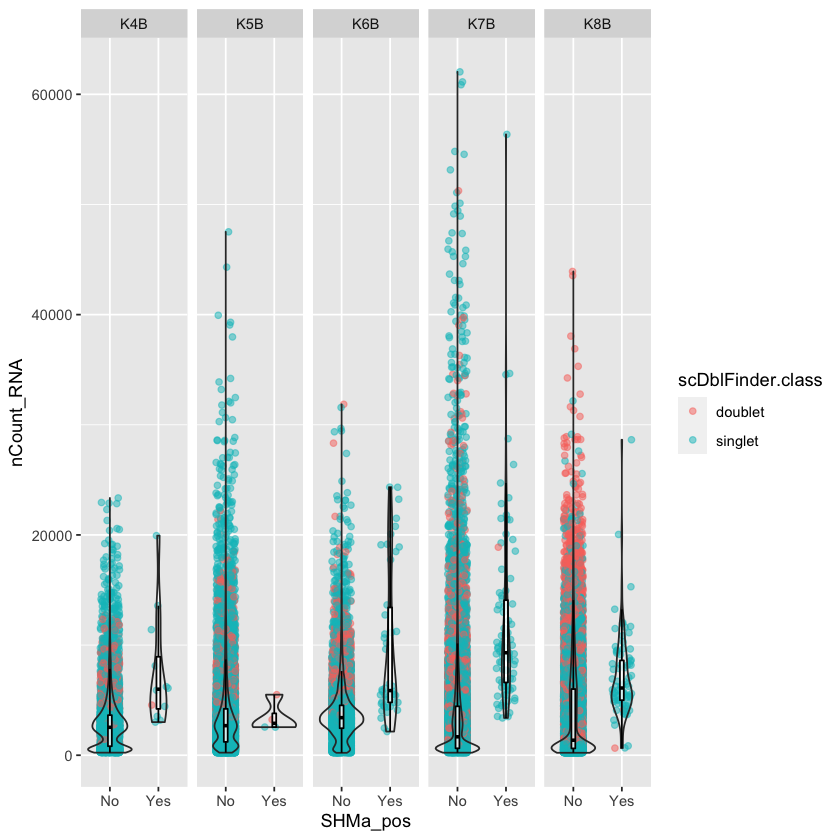

In [19]:
raw_con <- ggplot(dou_k45678, aes(y = nCount_RNA, x =SHMa_pos)) +
  geom_point(aes(colour = scDblFinder.class),position = position_jitterdodge(seed = 2, dodge.width = 0), alpha=0.5) + #aes(colour = type)
    geom_violin(position = position_dodge(width = 0.9), alpha=0.8,fill =NA) +
       geom_boxplot(width = 0.08,position = position_dodge(width = 0.6),color="black",outlier.shape = NA,alpha=0.8 ) +
        facet_grid(.~experiment)

fig_save(raw_con, filename = "figs/FL/raw_RNA_counts_SHM_events_scDblFinder_K45678", formats = c("pdf", "png"), width = 20, height = 15, units = "cm", dpi = 320)

raw_con